# 02 Measuring Valence

**Can valence be measured and validated from free text?**

This project describes comments in terms of **core affect**: the two dimensions of valence (pleasantness) and arousal (activation) that Russell (1980) arranged as a circumplex and that Barrett & Russell (1999) treat as the substrate of momentary feeling. Core affect is not the same thing as an emotion. Named emotions such as anger or disappointment are built on top of it, through learned concepts, language and context — so this project measures the substrate and does not try to recover the labels.

This notebook focuses on valence, the pleasantness dimension of core affect. The goal is to determine whether valence can be measured reliably from free-text employee comments.

The challenge is validation. While thousands of employees provided written feedback, none of the comments were manually labelled for valence.

Instead of relying on human annotation, this project uses an independent source of information. Each respondent not only provided a written comment but also answered 54 closed-ended survey questions. These survey responses serve as an external reference for evaluating whether text-derived valence scores reflect the experiences reported by the same individuals.

The central assumption is straightforward:

> Employees who express more positive experiences in their comments should also report more positive experiences in the survey.

To test this assumption, valence scores are compared against six survey-based criteria:

| Criterion | Why |
|------------|------|
| `arbeitsfreude` | Closest direct measure of positive affect at work |
| `arbeitgeber_empfehlung` | Willingness to recommend the employer |
| `teamstimmung` | Perceived team atmosphere |
| `work_life_balance` | Perceived balance between work and private life |
| `engagement_score` | Average across five engagement-related items |
| `overall_score` | Average across all 54 survey items |

These criteria are not fully independent. Some individual survey items contribute to the aggregated scores, meaning the six measures should be interpreted as overlapping validation criteria rather than six completely independent tests.

The validation approach is therefore simple: generate valence scores from free-text comments and examine how strongly they align with the survey responses of the same participants.

---

In [1]:
# ============================================================
# Imports
# ============================================================

import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)

DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. This run's outputs, and the outputs stored inside this")
    print("notebook's cells, contain real employee comments. Do not share the")
    print("executed copy.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

CLEAN = WORK / f"{SOURCE}_clean.parquet"
OUTPUT = WORK / f"{SOURCE}_valence.parquet"

# ---- what to compute --------------------------------------------------------
# The LLM stage takes about 5 seconds per comment. Existing scores are loaded when
# available. Set RECOMPUTE = True to rerun the scoring step; results remain
# unchanged because the model is deterministic.

RECOMPUTE = False

OLLAMA = "http://127.0.0.1:11434"
LLM_MODEL = "gemma2:9b"
BERT_MODEL = "oliverguhr/german-sentiment-bert"

CRITERIA = ["arbeitsfreude", "arbeitgeber_empfehlung", "teamstimmung",
            "work_life_balance", "engagement_score", "overall_score"]

BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

data = pd.read_parquet(CLEAN)
comments = data[data["has_comment"] == 1].copy()
print(f"{len(data):,} responses, {len(comments):,} with a comment")

5,000 responses, 2,500 with a comment


---

## Step 1: Establishing a Baseline

As a baseline, the first model tested is *german-sentiment-bert*. It predicts the probability that a comment is positive, negative, or neutral.

To create a continuous valence score, two methods are compared.

**Simple difference:** `positive − negative`

A positive score indicates more positive than negative language, while a negative score indicates the opposite. However, strongly neutral comments tend to receive values close to zero.

**Neutrality-adjusted difference:** `(positive − negative) / (positive + negative)`

This version removes the influence of the neutral class and focuses only on the competition between positive and negative signals.

The goal is to determine which representation aligns more closely with the survey responses of the same participants.

In [2]:
# ============================================================
# BERT Sentiment
# ============================================================

BERT_CACHE = WORK / f"{SOURCE}_bert_sentiment.parquet"

if BERT_CACHE.exists() and not RECOMPUTE:
    sentiment = pd.read_parquet(BERT_CACHE)
    print(f"loaded {BERT_CACHE.name}")
else:
    from transformers import pipeline

    print(f"running {BERT_MODEL} on {len(comments):,} comments …", flush=True)
    classifier = pipeline("sentiment-analysis", model=BERT_MODEL, top_k=None)

    started = time.time()
    rows = []
    for text in comments["freitext_kommentar"]:
        scores = {item["label"]: item["score"]
                  for item in classifier(text, truncation=True)[0]}
        rows.append(scores)
    sentiment = pd.DataFrame(rows, index=comments.index)
    sentiment.to_parquet(BERT_CACHE)
    print(f"done in {(time.time() - started) / 60:.1f} min")

positive, negative = sentiment["positive"], sentiment["negative"]
comments["bert_simple"] = positive - negative
comments["bert_adjusted"] = (positive - negative) / (positive + negative)

print(comments[["bert_simple", "bert_adjusted"]]
      .describe().loc[["mean", "std", "25%", "50%", "75%"]].round(3).to_string())

loaded synthetic_bert_sentiment.parquet
      bert_simple  bert_adjusted
mean        0.206          0.180
std         0.818          0.858
25%        -0.862         -0.894
50%         0.512          0.763
75%         0.985          0.986


In [3]:
# ============================================================
#  Interim check: How far does the sentiment model get?
# ============================================================
# Agreement with the survey items of the same respondents, plus how much of the
# scale the measure actually uses.

for label, column in [("BERT: simple difference", "bert_simple"),
                      ("BERT: neutral-adjusted", "bert_adjusted")]:
    values = []
    for criterion in CRITERIA:
        pair = comments[[column, criterion]].dropna()
        values.append(pair[column].corr(pair[criterion], method="spearman"))
    extreme = (comments[column].abs() > 0.9).mean()
    print(f"{label:26s} mean Spearman {np.mean(values):+.3f}   "
          f"{extreme:.0%} of values beyond |0.9|")

print("\nVerdict: both agree with the survey, so the text does carry signal.")
print("However, most values sit at the extremes of the scale, limiting the")
print("ability to distinguish between moderately positive and negative comments.")
print("The next step asks a language model instead.")

BERT: simple difference    mean Spearman +0.304   65% of values beyond |0.9|
BERT: neutral-adjusted     mean Spearman +0.306   68% of values beyond |0.9|

Verdict: both agree with the survey, so the text does carry signal.
However, most values sit at the extremes of the scale, limiting the
ability to distinguish between moderately positive and negative comments.
The next step asks a language model instead.


Both BERT variants show meaningful agreement with the survey criteria, indicating that employee comments contain detectable sentiment information.

However, most scores accumulate near the boundaries of the scale. The models can distinguish positive from negative comments, but provide limited resolution within those broad categories.

The next step therefore evaluates a language-model approach that may produce a more differentiated valence measure.

---

## Step 2: Using a Large Language Model

The baseline approach relies on a traditional sentiment model. As a second approach, a large language model is asked to estimate valence directly from the written comment.

The model used is `gemma2:9b`, running locally so that all comments remain on the machine.

Two prompting strategies were evaluated:

**Anchored:** The language model receives the sentiment score generated by BERT and is asked to refine it.

**Blind:** The language model receives only the comment and estimates valence independently.

The blind approach performed better during validation. Providing the BERT score reduced the independence of the assessment and often resulted in predictions that closely followed the initial BERT estimate.

The following analyses therefore use the blind prompting approach.

In [4]:
# ============================================================
# The Prompt
# ============================================================

FENCE = chr(34) * 3
# FENCE = '"""'

LLM_PROMPT = (
    "You are an expert in emotion analysis of German-language employee feedback.\n\n"
    "Assess the emotional valence the author of the following comment expresses.\n\n"
    "Valence scale:\n"
    "-1.0 = extremely negative\n"
    "-0.5 = clearly negative\n"
    " 0.0 = neutral, factual, or evenly mixed\n"
    " 0.5 = clearly positive\n"
    " 1.0 = extremely positive\n\n"
    "Guidance:\n\n"
    "1. Judge the comment as a whole, not individual emotionally charged words.\n"
    "2. A constructive suggestion or a factual question is not automatically negative.\n"
    "3. Use intermediate values. Reserve values beyond -0.9 or +0.9 for genuinely "
    "extreme emotion.\n"
    "4. If praise and criticism are both present, weigh them against each other.\n\n"
    "Return JSON only, nothing else:\n\n"
    '{{"valence": 0.00}}\n\n'
    "Employee comment:\n\n"
    + FENCE + "\n{comment}\n" + FENCE + "\n"
)

print(LLM_PROMPT.format(comment="<Kommentar>")[:420] + " …")

You are an expert in emotion analysis of German-language employee feedback.

Assess the emotional valence the author of the following comment expresses.

Valence scale:
-1.0 = extremely negative
-0.5 = clearly negative
 0.0 = neutral, factual, or evenly mixed
 0.5 = clearly positive
 1.0 = extremely positive

Guidance:

1. Judge the comment as a whole, not individual emotionally charged words.
2. A constructive sugge …


### Source of the Valence Scores

The valence scores used in this notebook have already been generated and are loaded from file.

For the **synthetic dataset**, valence was defined during data generation and subsequently used to derive the associated survey responses. This creates a known relationship between comments and survey ratings and provides a useful benchmark for evaluating the validation approach.

For the **real dataset**, valence was calculated in a separate scoring pipeline before the validation step. Each comment was evaluated independently by the local Gemma 2 9B model using the blind prompting approach described above.

The scoring process is deterministic, meaning that rerunning the pipeline with the same configuration produces identical valence scores.

In [5]:
# ============================================================
# LLM Valence
# ============================================================

def score_one(comment: str) -> float | None:
    try:
        response = requests.post(f"{OLLAMA}/api/chat", json={
            "model": LLM_MODEL,
            "messages": [{"role": "user", "content": LLM_PROMPT.format(comment=comment)}],
            "stream": False, "keep_alive": "1h",
            "options": {"temperature": 0, "seed": 42, "num_predict": 30},
        }, timeout=180)
        response.raise_for_status()
        match = re.search(r"-?\d+\.?\d*", response.json()["message"]["content"])
        return max(-1.0, min(1.0, float(match.group()))) if match else None
    except Exception as error:
        print(f"  failed: {error}")
        return None


CHECKPOINTS = {
    "synthetic": WORK / "synthetic_valence_checkpoint.jsonl",
    "real": WORK / "valence_checkpoint.jsonl",
}
scored: dict[str, float] = {}

if SOURCE == "synthetic" and not RECOMPUTE:
    # the generator keyed its checkpoint by spec_id, so it is joined via the text
    generated = CHECKPOINTS["synthetic"]
    written = WORK / "synthetic_comments_checkpoint.jsonl"
    if generated.exists() and written.exists():
        texts = {}
        with written.open(encoding="utf-8") as handle:
            for line in handle:
                record = json.loads(line)
                texts[record["spec_id"]] = record["text"]
        with generated.open(encoding="utf-8") as handle:
            for line in handle:
                record = json.loads(line)
                if record.get("valence") is not None and record["spec_id"] in texts:
                    scored[texts[record["spec_id"]]] = record["valence"]
        print(f"loaded {len(scored):,} scores from the generation step")

elif SOURCE == "real" and not RECOMPUTE:
    export = DATA / "results" / "valence_gemma_blind_full.parquet"
    base = DATA / "results" / "high5_valence_validated.parquet"
    if export.exists() and base.exists():
        blind = pd.read_parquet(export)
        original = pd.read_parquet(base)["freitext_kommentar"]
        for row_id, value in zip(blind["row_id"], blind["valence"]):
            text = str(original.iloc[row_id]).strip()
            if text and pd.notna(value):
                scored[text] = float(value)
        print(f"loaded {len(scored):,} scores from 03_b_gemma_valence_full_blind")

missing = [t for t in comments["freitext_kommentar"] if t not in scored]
if missing:
    import requests

    print(f"{len(missing):,} comments still to score "
          f"(~{len(missing) * 5 / 3600:.1f} h)", flush=True)
    checkpoint = WORK / f"{SOURCE}_valence_llm.jsonl"
    if checkpoint.exists():
        with checkpoint.open(encoding="utf-8") as handle:
            for line in handle:
                record = json.loads(line)
                if record.get("valence") is not None:
                    scored[record["text"]] = record["valence"]
        missing = [t for t in comments["freitext_kommentar"] if t not in scored]

    started = time.time()
    with checkpoint.open("a", encoding="utf-8") as handle:
        for position, text in enumerate(dict.fromkeys(missing), start=1):
            value = score_one(text)
            handle.write(json.dumps({"text": text, "valence": value},
                                    ensure_ascii=False) + "\n")
            handle.flush()
            if value is not None:
                scored[text] = value
            if position % 100 == 0:
                rate = (time.time() - started) / position
                print(f"  {position:,} done, {rate:.1f}s each", flush=True)

comments["llm_valence"] = comments["freitext_kommentar"].map(scored)
print(f"\n{comments['llm_valence'].notna().sum():,} of {len(comments):,} comments scored")

loaded 2,497 scores from the generation step

2,500 of 2,500 comments scored


In [6]:
# ============================================================
# Interim Check: Is the language model better?
# ============================================================

scored_now = comments["llm_valence"].notna().sum()
if scored_now < 30:
    print(f"only {scored_now} comments scored — run the cell above to completion first")
else:
    values = []
    for criterion in CRITERIA:
        pair = comments[["llm_valence", criterion]].dropna()
        values.append(pair["llm_valence"].corr(pair[criterion], method="spearman"))
    def mean_agreement(column):
        scores = []
        for criterion in CRITERIA:
            pair = comments[[column, criterion]].dropna()
            scores.append(pair[column].corr(pair[criterion], method="spearman"))
        return float(np.mean(scores))

    best_bert = max(mean_agreement("bert_simple"), mean_agreement("bert_adjusted"))

    print(f"Gemma: blind               mean Spearman {np.mean(values):+.3f}")
    print(f"best BERT variant          mean Spearman {best_bert:+.3f}")
    print(f"beyond |0.9|               {(comments['llm_valence'].abs() > 0.9).mean():.0%}")
    print(f"distinct values            {comments['llm_valence'].nunique()}")

    if np.mean(values) > best_bert:
        print("\nVerdict: The language-model score shows stronger agreement with")
        print("the survey criteria and uses more of the scale than the BERT baselines.")
        print("It is therefore retained as the valence measure for the following analyses.")
        print("One limitation, examined below, is that the score is still relatively coarse.")
    else:
        print("\nVerdict: The language-model score does not improve on the sentiment model")
        print("on this corpus.")

Gemma: blind               mean Spearman +0.393
best BERT variant          mean Spearman +0.306
beyond |0.9|               0%
distinct values            18

Verdict: The language-model score shows stronger agreement with
the survey criteria and uses more of the scale than the BERT baselines.
It is therefore retained as the valence measure for the following analyses.
One limitation, examined below, is that the score is still relatively coarse.


The language-model score improves on the BERT-based baselines. It shows stronger average agreement with the survey criteria and avoids the strong saturation observed in the simple sentiment scores.

This makes it the preferred valence measure for the following analyses. Its main limitation is granularity: the model uses more of the scale than BERT, but still produces a limited number of distinct score values.

---

## Step 3: Which Measure Best Reflects the Survey Results?

To evaluate the different valence measures, each score is compared with the survey criteria using Spearman correlation.

Spearman correlation measures whether two variables move in the same direction. A high positive correlation means that higher valence scores tend to occur together with more positive survey responses, while a negative correlation indicates the opposite relationship.

Spearman was chosen because the survey criteria are based on five-point Likert scales. Rather than comparing exact distances between values, Spearman focuses on the relative ordering of responses, making it well suited for ordinal survey data.

Stronger correlations indicate closer agreement between the text-derived valence scores and the survey responses of the same participants.

In [7]:
# ============================================================
# Validation
# ============================================================

CANDIDATES = {"BERT: simple difference": "bert_simple",
              "BERT: neutral-adjusted": "bert_adjusted",
              "Gemma: blind": "llm_valence"}

rows = []
for label, column in CANDIDATES.items():
    row = {"measure": label}
    for criterion in CRITERIA:
        pair = comments[[column, criterion]].dropna()
        row[criterion] = pair[column].corr(pair[criterion], method="spearman")
    row["mean"] = np.mean([row[c] for c in CRITERIA])
    rows.append(row)

validation = pd.DataFrame(rows).set_index("measure")
print(validation.round(3).to_string())

winner = validation["mean"].idxmax()
print(f"\nWinner: {winner}   (mean Spearman {validation.loc[winner, 'mean']:+.3f})")
print("\nRemember that four of the six criteria overlap: arbeitgeber_empfehlung,")
print("arbeitsfreude and work_life_balance are components of engagement_score, and")
print("overall_score averages over all items. Effectively three criterion groups.")

                         arbeitsfreude  arbeitgeber_empfehlung  teamstimmung  work_life_balance  engagement_score  overall_score   mean
measure                                                                                                                                
BERT: simple difference          0.336                   0.335         0.230              0.244             0.335          0.346  0.304
BERT: neutral-adjusted           0.336                   0.338         0.230              0.245             0.336          0.348  0.306
Gemma: blind                     0.417                   0.436         0.318              0.303             0.427          0.453  0.393

Winner: Gemma: blind   (mean Spearman +0.393)

Remember that four of the six criteria overlap: arbeitgeber_empfehlung,
arbeitsfreude and work_life_balance are components of engagement_score, and
overall_score averages over all items. Effectively three criterion groups.


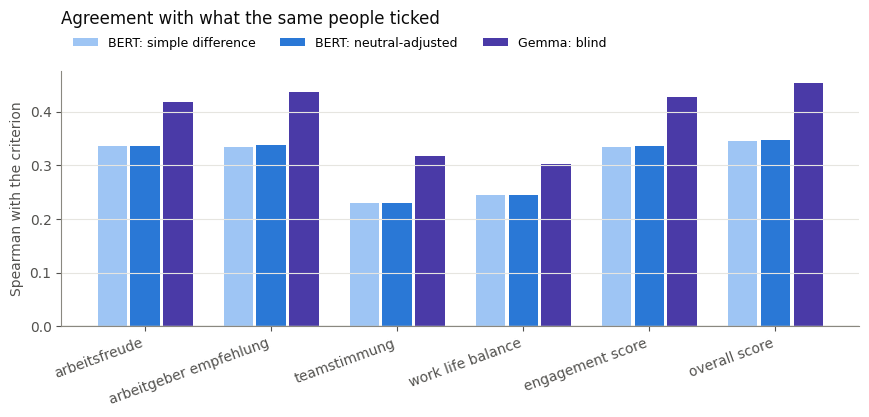

In [8]:
# ============================================================
# The Comparison as a Picture
# ============================================================

fig, ax = plt.subplots(figsize=(9.5, 4.4))
fig.subplots_adjust(left=0.13, right=0.97, top=0.80, bottom=0.22)

colours = {"BERT: simple difference": "#9ec5f4", "BERT: neutral-adjusted": BLUE,
           "Gemma: blind": VIOLET}
width, offsets = 0.26, np.arange(len(CANDIDATES)) - 1
positions = np.arange(len(CRITERIA))

for offset, (label, column) in zip(offsets, CANDIDATES.items()):
    values = [validation.loc[label, c] for c in CRITERIA]
    ax.bar(positions + offset * width, values, width * 0.9,
           label=label, color=colours[label])

ax.set_xticks(positions)
ax.set_xticklabels([c.replace("_", " ") for c in CRITERIA], rotation=20, ha="right")
ax.set_ylabel("Spearman with the criterion")
ax.grid(axis="x", visible=False)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncols=3, fontsize=9)
ax.set_title("Agreement with what the same people ticked", fontsize=12, loc="left", pad=34)
plt.show()

Gemma outperforms both BERT-based approaches across all validation criteria. The strongest relationships are observed for `overall_score` (ρ = 0.453), `arbeitgeber_empfehlung` (ρ = 0.436), and `engagement_score` (ρ = 0.427).

The two BERT variants produce very similar results, suggesting that the neutrality adjustment has only a limited effect in this dataset. In contrast, the LLM-based approach captures more of the variation reflected in the survey responses.

Overall, the results indicate that direct valence estimation with a large language model provides a closer representation of employees' reported experiences than a traditional sentiment classifier.

---

## Step 4: Why the Simple Difference Falls Short

The validation results show that the baseline performs less well than the LLM-based approach. Understanding why helps explain the differences observed in the validation step.

The simple difference

`positive − negative`

works well when comments are assigned a balanced mix of positive and negative probabilities. In practice, however, the sentiment model is often highly confident and assigns most of the probability mass to a single class.

As a result, many comments receive scores very close to the extremes of the scale. Different comments may therefore end up with very similar scores, even when their emotional tone differs substantially.

This limits the model's ability to distinguish between mildly positive, strongly positive, and exceptionally positive comments. A useful valence measure should not only separate positive from negative responses but also capture differences in intensity.

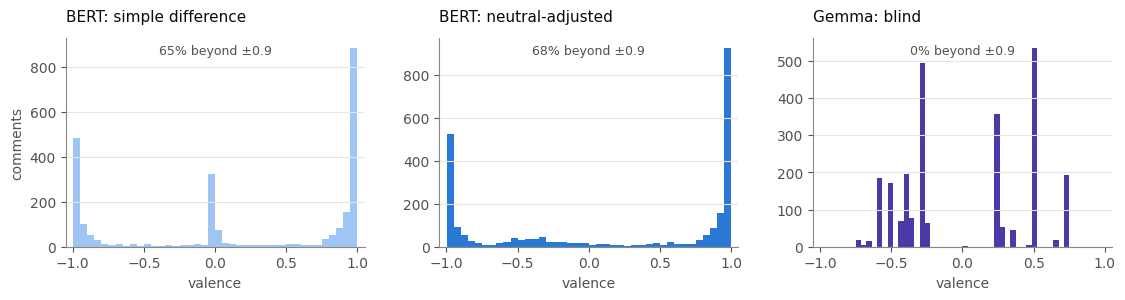

BERT: simple difference    median +0.51   beyond |0.9|: 65%   distinct values: 2,497
BERT: neutral-adjusted     median +0.76   beyond |0.9|: 68%   distinct values: 2,497
Gemma: blind               median -0.25   beyond |0.9|: 0%   distinct values: 18


In [9]:
# ============================================================
# Saturation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
fig.subplots_adjust(wspace=0.25, top=0.78, bottom=0.20)

for ax, (label, column) in zip(axes, CANDIDATES.items()):
    ax.hist(comments[column].dropna(), bins=40, color=colours[label])
    ax.set_title(label, fontsize=11, loc="left", pad=12)
    ax.set_xlim(-1.05, 1.05)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("valence")
    extreme = (comments[column].abs() > 0.9).mean()
    ax.text(0.5, 0.92, f"{extreme:.0%} beyond ±0.9", transform=ax.transAxes,
            ha="center", color=INK_SOFT, fontsize=9)
axes[0].set_ylabel("comments")
plt.show()

for label, column in CANDIDATES.items():
    series = comments[column].dropna()
    print(f"{label:26s} median {series.median():+.2f}   "
          f"beyond |0.9|: {(series.abs() > 0.9).mean():.0%}   "
          f"distinct values: {series.nunique():,}")

The distributions help explain the validation results. Both BERT-based measures place most comments near the extremes of the scale, with roughly two thirds of all scores falling beyond ±0.9. As a result, many comments receive very similar values, limiting the model's ability to distinguish between different levels of positivity or negativity.

In contrast, the Gemma scores are distributed across a much broader range of the scale. This allows finer distinctions between comments and likely contributes to the stronger correlations observed in the validation step.

---

## Step 5: Limitations of the Winning Approach

The Gemma-based measure achieves the strongest agreement with the survey data, but it is not without limitations.

Unlike a continuous scoring function, the language model tends to reuse a relatively small set of score values. As a result, comments are often assigned identical or very similar valence scores rather than spreading smoothly across the full scale.

In the real dataset, the model produced only 27 distinct score values, with many comments concentrated at a few common points. Some parts of the scale were not used at all.

This limited resolution is unlikely to affect analyses based on proportions, averages, or overall trends. However, it may become relevant when comparing very similar comments or when ranking individual comments, teams, or organizational units.

distinct values: 18
largest share on one value: 21% (at +0.50)
largest gap between neighbouring values: 0.25


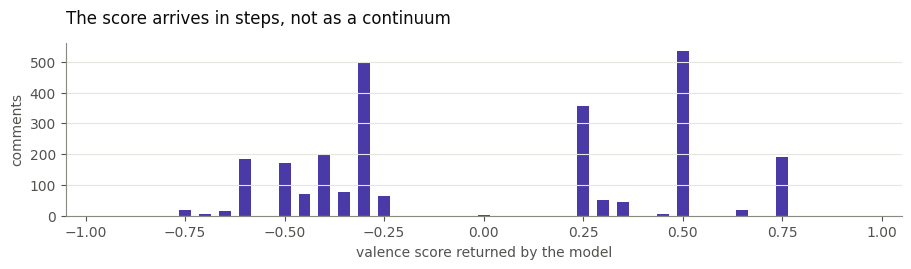

In [10]:
# ============================================================
# How Coarse Is It?
# ============================================================

levels = comments["llm_valence"].value_counts().sort_index()
print(f"distinct values: {len(levels)}")
print(f"largest share on one value: {levels.max() / levels.sum():.0%} "
      f"(at {levels.idxmax():+.2f})")
gaps = np.diff(levels.index)
print(f"largest gap between neighbouring values: {gaps.max():.2f}")

fig, ax = plt.subplots(figsize=(9.5, 3.2))
fig.subplots_adjust(left=0.09, right=0.97, top=0.78, bottom=0.24)
ax.bar(levels.index, levels.values, width=0.03, color=VIOLET)
ax.set_xlim(-1.05, 1.05)
ax.grid(axis="x", visible=False)
ax.set_xlabel("valence score returned by the model")
ax.set_ylabel("comments")
ax.set_title("The score arrives in steps, not as a continuum",
             fontsize=12, loc="left", pad=14)
plt.show()

---

## Step 6 — Hand over

In [11]:
# ============================================================
# Export
# ============================================================

export = data.copy()
for column in ["bert_simple", "bert_adjusted", "llm_valence"]:
    export[column] = comments[column].reindex(export.index)
export = export.rename(columns={"llm_valence": "valence"})

# a rank-normalised twin, for anything that needs a uniform scale
export["valence_rank"] = export["valence"].rank(pct=True) * 2 - 1

export.to_parquet(OUTPUT, index=False)
validation.to_csv(WORK / f"{SOURCE}_valence_validation.csv", sep=";",
                  encoding="utf-8-sig", decimal=",")
print(f"written: {OUTPUT.name}   {len(export):,} rows")
print(f"         {SOURCE}_valence_validation.csv")

written: synthetic_valence.parquet   5,000 rows
         synthetic_valence_validation.csv


---

## Key Findings

Valence can be measured from free-text employee comments, and the resulting scores can be validated without manually annotating a single comment.

Three findings emerge from the analysis:

**Survey responses provide a useful validation criterion.** All candidate measures show positive correlations with the survey data, with the strongest relationships observed for work enjoyment, employer recommendation, and overall engagement.

**Direct valence estimation with a large language model performs best.** The Gemma-based approach consistently achieves stronger agreement with the survey criteria than the sentiment-based baselines.

**The best-performing measure has limited granularity.** While it performs well for group-level analyses, it produces a relatively small number of distinct score values and is therefore less suitable for ranking highly similar comments or individuals.

Overall, the results support the use of LLM-based valence estimation as the foundation for the circumplex and topic analyses that follow.

## Comparing Synthetic and Real Data

The overall ranking of methods is consistent across both datasets: the Gemma-based approach performs best, followed by the BERT-based alternatives.

However, the performance differences are smaller on the synthetic dataset. The synthetic comments appear to provide a clearer sentiment signal, allowing the BERT-based approaches to recover more of the underlying variation than they do on real employee feedback.

As a result, the gap between Gemma and the BERT-based measures is reduced, even though the overall ranking of methods remains unchanged.

This illustrates an important limitation of synthetic text: analytical results often generalize more reliably than effect sizes. The ordering of methods is preserved, but performance differences may not transfer directly to real-world data.

In [12]:
# ============================================================
# Against the Real Data
# ============================================================

REAL = {"BERT: simple difference": None, "BERT: neutral-adjusted": 0.259,
        "Gemma: blind": 0.389, "Gemma: anchored": 0.361}

print(f"{'measure':28s} {'here':>9s} {'real survey':>13s}")
for label, real in REAL.items():
    here = validation.loc[label, "mean"] if label in validation.index else None
    shown_here = f"{here:+.3f}" if here is not None else "not run"
    shown_real = f"{real:+.3f}" if real is not None else "--"
    print(f"{label:28s} {shown_here:>9s} {shown_real:>13s}")

margin = (validation.loc["Gemma: blind", "mean"]
          - validation.loc["BERT: neutral-adjusted", "mean"])
print(f"\nwinner's margin over BERT neutral-adjusted")
print(f"  here         {margin:+.3f}")
print(f"  real survey  {0.389 - 0.259:+.3f}")

print(f"\ndistinct values of the winner: {comments['llm_valence'].nunique()}"
      f"   (real survey: 27)")
print(f"BERT simple, share beyond |0.9|: "
      f"{(comments['bert_simple'].abs() > 0.9).mean():.0%}")

# The level and direction of the real distribution are not reported here: they are
# findings about the workforce, not properties of the method.

measure                           here   real survey
BERT: simple difference         +0.304            --
BERT: neutral-adjusted          +0.306        +0.259
Gemma: blind                    +0.393        +0.389
Gemma: anchored                not run        +0.361

winner's margin over BERT neutral-adjusted
  here         +0.087
  real survey  +0.130

distinct values of the winner: 18   (real survey: 27)
BERT simple, share beyond |0.9|: 65%


Although saturation is more pronounced in the synthetic dataset, the same tendency to concentrate scores near the boundaries is also observed in the real data. This suggests that the effect is driven primarily by the scoring method itself rather than by the use of synthetic comments.